In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

inventory = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')

/tmp/ipykernel_3137/1928169922.py:11: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  inventory = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')


## Functions

In [4]:
# Cleaning functions
# TASK 1
def fix_na_carrier(df):
    """
    Fixes error where 'NA', North American Airlines, was read as a missing value
    """
    df_cleaned = df.copy()

    mask = (df_cleaned['CARRIER_NAME'] == 'North American Airlines') & (df_cleaned['CARRIER'].isnull())
    df_cleaned.loc[mask, 'CARRIER'] = 'NA'

    mask_unique = (df_cleaned['CARRIER_NAME'] == 'North American Airlines') & (df_cleaned['UNIQUE_CARRIER'].isnull())
    df_cleaned.loc[mask_unique, 'UNIQUE_CARRIER'] = 'NA'

    return df_cleaned

def impute_using_median(df):
    """
    Imputes MANUFACTURE_YEAR, NUMBER_OF_SEATS, and CAPACITY_IN_POUNDS using the
    median manufacture year of the same aircraft MODEL.

    This makes sense because airplanes of the same model typically:
        - Are made around the same time
        - Have the same number of seats
        - Are similar in size

    What this means is that the missing data in NUMBER_OF_SEATS and
    CAPACITY_IN_POUNDS is MAR because it can be explained by other variables.
    The way that the data does not get reported is systematic (model).

    """
    df_cleaned = df.copy()

    df_cleaned['MANUFACTURE_YEAR'] = df_cleaned.groupby('MODEL')['MANUFACTURE_YEAR'].transform(lambda x: x.fillna(x.median()))
    df_cleaned['NUMBER_OF_SEATS'] = df_cleaned.groupby('MODEL')['NUMBER_OF_SEATS'].transform(lambda x: x.fillna(x.median()))
    df_cleaned['CAPACITY_IN_POUNDS'] = df_cleaned.groupby('MODEL')['CAPACITY_IN_POUNDS'].transform(lambda x: x.fillna(x.median()))

    return df_cleaned

def impute_airline_id(df):
    """
    Imputes missing AIRLINE_ID values by looking up the ID associated with the
    same CARRIER_NAME. As seen through inspection, the airline_id is constant
    across carrier names.
    """
    df_cleaned = df.copy()

    df_cleaned['AIRLINE_ID'] = df_cleaned.groupby('CARRIER_NAME')['AIRLINE_ID'].transform(lambda x: x.fillna(x.max()))

    return df_cleaned

# Task 2
def standardize_columns(df):
    """
    Standardizes the 'problem columns' by converting all data to str, making it
    uppercase, then stripping the whitespace
    """
    df_cleaned = df.copy()
    prob_cols = ['MANUFACTURER', 'MODEL', 'AIRCRAFT_STATUS', 'OPERATING_STATUS']

    for col in prob_cols:
        if col in df_cleaned.columns:
            df_cleaned[col] = df_cleaned[col].astype(str).str.upper().str.strip()

    return df_cleaned

def standardize_manufacturer(df):
    """
    Uses regex to standardize the manufacturers by just the first word. This
    function could consolidate unique values in certain scenarios but for the
    purposes of having a "big win" and this dataset, this should suffice

    Note: used AI for this function to help with the regex (my idea though)
    """
    df_cleaned = df.copy()

    # The RegEx r'^([A-Z]+)' means:
    # ^      : Start at the beginning of the string
    # [A-Z]+ : Match one or more uppercase letters (stopping at spaces or punctuation)
    # expand=False returns a Series instead of a DataFrame
    df_cleaned['MANUFACTURER'] = df_cleaned['MANUFACTURER'].str.extract(r'^([A-Z]+)', expand=False)

    return df_cleaned

# Task 3
def remove_missing_rows(df):
    """
    Removes rows that still have missing data. Also prints the rows remaining as
    well as the rows removed
    """
    df_cleaned = df.copy()
    before = df_cleaned.shape[0]
    df_cleaned = df.dropna()

    after = df_cleaned.shape[0]

    print(f'{before - after} rows removed')
    print(f'{after} rows remaining')

    return df_cleaned

# Task 4
def check_skewness(df):
    """
    Checks the skew of NUMBER_OF_SEATS and CAPACITY_IN_POUNDS, also plots them
    """

    print(df[['NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS']].skew())

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.histplot(df['NUMBER_OF_SEATS'], kde=True, ax=axes[0], color='blue')
    axes[0].set_title('NUMBER_OF_SEATS skew (not transformed)')

    sns.histplot(df['CAPACITY_IN_POUNDS'], kde=True, ax=axes[1], color='orange')
    axes[1].set_title('CAPACITY_IN_POUNDS skew (not transformed)')

    plt.tight_layout()
    plt.show()


def apply_boxcox(df):
    """
    Applies the boxcox transformation to specific numerical columns to
    normalize them. Saves the results as new columns with a _BOXCOX suffix. Also
    plots the transformed histogram
    """
    df_transformed = df.copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    c = 0
    colors = ['blue', 'orange']

    for col in ['NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS']:
        # Get rid of zero value data (bad for boxcox)
        safe_col = df_transformed[col] + 1e-6

        transformed_data, _ = stats.boxcox(safe_col)

        new_col_name = f'{col}_BOXCOX'

        df_transformed[new_col_name] = transformed_data

        sns.histplot(df_transformed[new_col_name], kde=True, ax=axes[c], color=colors[c])
        axes[c].set_title(f'Transformed: {new_col_name}')
        c += 1

    plt.tight_layout()
    plt.show()

    return df_transformed

# Task 5
def create_size_feature(df):
    """
    Creates new SIZE column based on the quartiles of NUMBER_OF_SEATS. Also
    plots the proportions of aircrafts that are operating (per size) and of
    aircrafts belonging to each aicraft status group (again, per size)
    """
    df_size = df.copy()

    q25 = df_size['NUMBER_OF_SEATS'].quantile(0.25)
    q50 = df_size['NUMBER_OF_SEATS'].quantile(0.50)
    q75 = df_size['NUMBER_OF_SEATS'].quantile(0.75)

    boundaries = [
        (df_size['NUMBER_OF_SEATS'] < q25),
        (df_size['NUMBER_OF_SEATS'] >= q25) & (df_size['NUMBER_OF_SEATS'] < q50),
        (df_size['NUMBER_OF_SEATS'] >= q50) & (df_size['NUMBER_OF_SEATS'] < q75),
        (df_size['NUMBER_OF_SEATS'] >= q75)
    ]


    sizes = ['SMALL', 'MEDIUM', 'LARGE', 'XLARGE']

    df_size['SIZE'] = np.select(boundaries, sizes, default=pd.NA)

    return df_size

def plot_props(df):
    """
    Calculates and plots the proportions of OPERATING_STATUS and AIRCRAFT_STATUS
    by aircraft SIZE.
    """
    sizes = ['SMALL', 'MEDIUM', 'LARGE', 'XLARGE']

    op_props = pd.crosstab(df['SIZE'], df['OPERATING_STATUS'], normalize='index').reindex(sizes)
    ac_props = pd.crosstab(df['SIZE'], df['AIRCRAFT_STATUS'], normalize='index').reindex(sizes)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    op_props.plot(kind='bar', stacked=True, colormap='viridis', ax=axes[0])
    axes[0].set_title('Proportion of Operating Status by Size')
    axes[0].set_ylabel('Proportion')
    axes[0].set_xlabel('Aircraft Size')
    axes[0].legend(title='Operating Status')

    ac_props.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[1])
    axes[1].set_title('Proportion of Aircraft Status by Size')
    axes[1].set_ylabel('Proportion')
    axes[1].set_xlabel('Aircraft Size')
    axes[1].legend(title='Aircraft Status', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

# Task 6
def model_refresh(df):
    """
    Splits data, trains regression models, and trains rf models. Also reports
    RMSE for training and testing.
    """


    cols = ['NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS']
    drop_cols = cols + ['NUMBER_OF_SEATS_BOXCOX', 'CAPACITY_IN_POUNDS_BOXCOX', 'SIZE',
        'TAIL_NUMBER', 'SERIAL_NUMBER', 'AIRLINE_ID', 'ACQUISITION_DATE',
        'MODEL', 'CARRIER_NAME', 'UNIQUE_CARRIER_NAME', 'CARRIER', 'UNIQUE_CARRIER', 'YEAR']


    X_raw = df.drop(columns=[col for col in drop_cols if col in df.columns])
    X = pd.get_dummies(X_raw, drop_first=True)
    print(X.shape)

    y_seats = df['NUMBER_OF_SEATS']
    y_capacity = df['CAPACITY_IN_POUNDS']

    X_train, X_test, y_train_seats, y_test_seats = train_test_split(X, y_seats, test_size=0.20, random_state=42)
    _, _, y_train_cap, y_test_cap = train_test_split(X, y_capacity, test_size=0.20, random_state=42)

    lr = LinearRegression()
    rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

    # Seats regression
    lr.fit(X_train, y_train_seats)
    train_rmse_lr_seats = np.sqrt(mean_squared_error(y_train_seats, lr.predict(X_train)))
    test_rmse_lr_seats = np.sqrt(mean_squared_error(y_test_seats, lr.predict(X_test)))

    # Capacity regression
    lr.fit(X_train, y_train_cap)
    train_rmse_lr_cap = np.sqrt(mean_squared_error(y_train_cap, lr.predict(X_train)))
    test_rmse_lr_cap = np.sqrt(mean_squared_error(y_test_cap, lr.predict(X_test)))

    # Seats rf
    rf.fit(X_train, y_train_seats)
    train_rmse_rf_seats = np.sqrt(mean_squared_error(y_train_seats, rf.predict(X_train)))
    test_rmse_rf_seats = np.sqrt(mean_squared_error(y_test_seats, rf.predict(X_test)))

    # Capacity rf
    rf.fit(X_train, y_train_cap)
    train_rmse_rf_cap = np.sqrt(mean_squared_error(y_train_cap, rf.predict(X_train)))
    test_rmse_rf_cap = np.sqrt(mean_squared_error(y_test_cap, rf.predict(X_test)))

    # Results
    results = pd.DataFrame({
        'Target': ['Seats', 'Seats', 'Capacity', 'Capacity'],
        'Model': ['Linear Regression', 'Random Forest', 'Linear Regression', 'Random Forest'],
        'Train RMSE': [train_rmse_lr_seats, train_rmse_rf_seats, train_rmse_lr_cap, train_rmse_rf_cap],
        'Test RMSE': [test_rmse_lr_seats, test_rmse_rf_seats, test_rmse_lr_cap, test_rmse_rf_cap]
    })

    return results


## Analysis

In [5]:
# Task 1
inv = fix_na_carrier(inventory)
inv = impute_using_median(inv)
inv = impute_airline_id(inv)



In [6]:
# Task 2
inv = standardize_columns(inv)
inv = standardize_manufacturer(inv)

In [7]:
# Task 3
inv = remove_missing_rows(inv)

43428 rows removed
88885 rows remaining


NUMBER_OF_SEATS      -0.260883
CAPACITY_IN_POUNDS    2.001876
dtype: float64


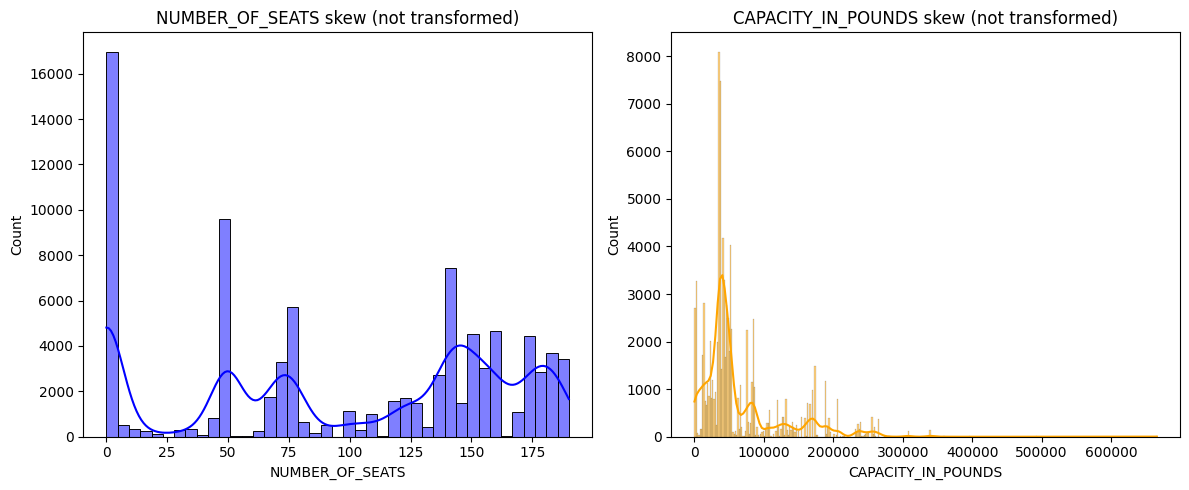

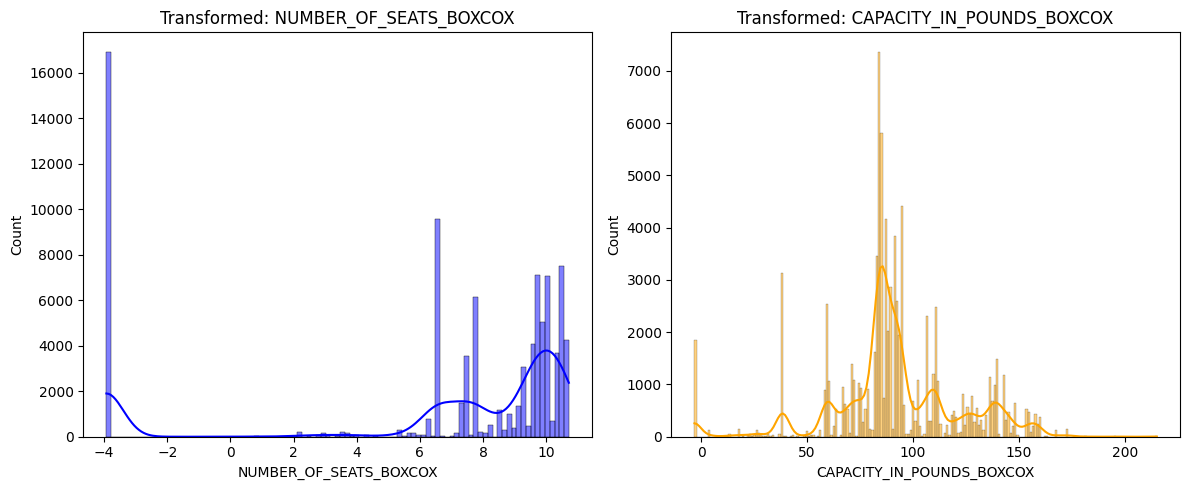

In [8]:
# Task 4
check_skewness(inv)
inv = apply_boxcox(inv)

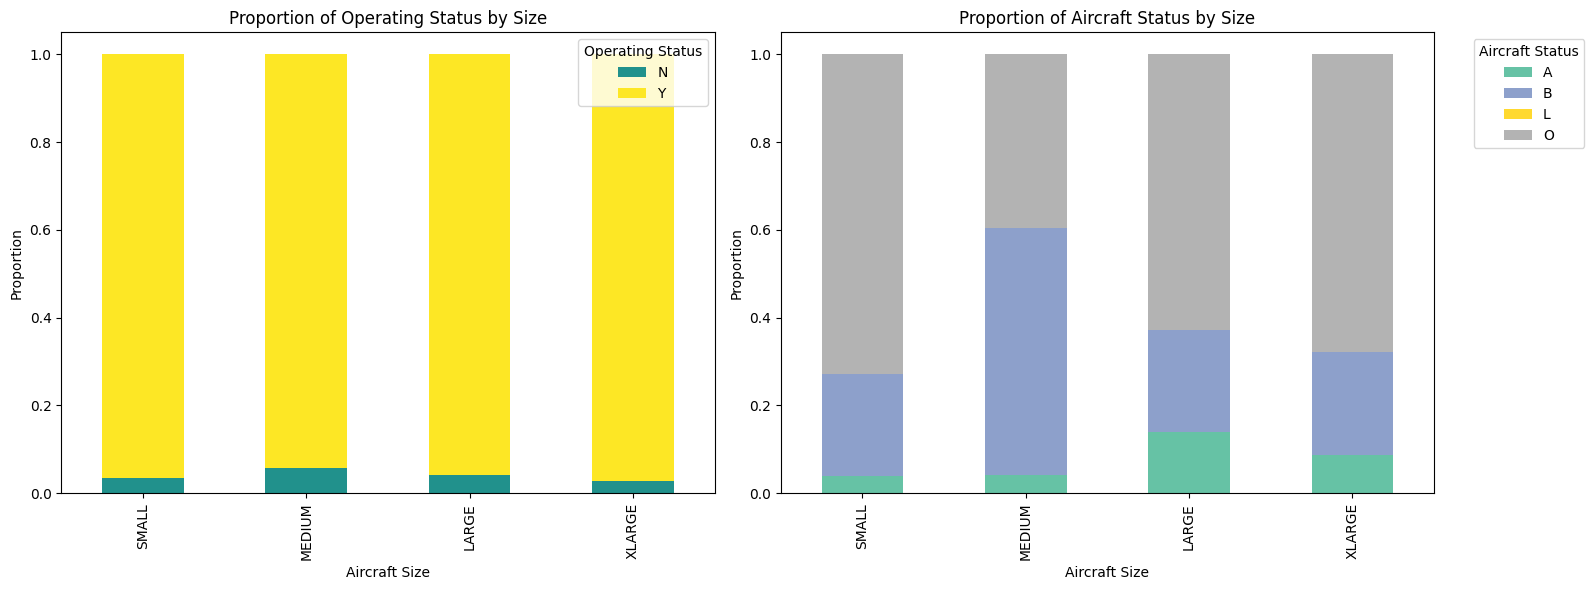

In [9]:
# Task 5
inv = create_size_feature(inv)
plot_props(inv)

In [10]:
# Task 6
model_refresh(inv)

(88885, 406)


,Target,Model,Train RMSE,Test RMSE
0,Seats,Linear Regression,11.402099,11.119664
1,Seats,Random Forest,7.357079,8.065016
2,Capacity,Linear Regression,32252.908646,32867.027087
3,Capacity,Random Forest,21410.380012,22731.667911


## Inspecting Data

In [ ]:
inv.columns

Index(['YEAR', 'CARRIER', 'CARRIER_NAME', 'MANUFACTURE_YEAR',
       'UNIQUE_CARRIER_NAME', 'SERIAL_NUMBER', 'TAIL_NUMBER',
       'AIRCRAFT_STATUS', 'OPERATING_STATUS', 'NUMBER_OF_SEATS',
       'MANUFACTURER', 'AIRCRAFT_TYPE', 'MODEL', 'CAPACITY_IN_POUNDS',
       'ACQUISITION_DATE', 'AIRLINE_ID', 'UNIQUE_CARRIER'],
      dtype='object')

In [ ]:
inv[inv['CARRIER_NAME'] == 'Tatonduk Flying Service']['AIRLINE_ID'].unique()

array([20408.])

In [ ]:
inv['MANUFACTURER'].unique()

array(['CANADAIR', 'CURTISS', 'MCDONNELL-DOUGLAS', 'PIPER', 'CESSNA',
       'EMBRAER', 'BOEING', 'AIRBUS', 'FOKKER', 'ATR', 'BELL',
       'FAIRCHILD', 'CONVAIR', 'LOCKHEED', 'SAAB AIRCRAFT', 'BAE',
       'BOMBARDIER', 'DEHAVILLAND', 'DASSULT SUD', 'BEECHCRAFT',
       'BOEING                                                                          ',
       'DORNIER                                                                         ',
       'IAI                                                                             ',
       'GULFSTREAM                                                                      ',
       'BOMBARDIER                                                                      ',
       'RAYTHEON                                                                        ',
       'CESSNA                                                                          ',
       'CANADAIR                                                                        ',
       

## Testing

In [ ]:
# Testing Functions
def missing_data_pct(df, column=None):
    """
    This function checks for missing data percetages of a dataset.
    Columns can be specified to check
    """
    if column:
        if column not in df.columns:
            return f'{column} not found in dataset'

        pct_missing = df[column].isnull().mean() * 100
        return f'{column}: {pct_missing:.2f}% missing data.'

    else:
        pct_missing = df.isnull().mean() * 100
        missing_df = pct_missing[pct_missing > 0].sort_values(ascending=False)
        if missing_df.empty:
            return 'No missing data found in the dataset'

        return missing_df

def imputation_possible(df):
    """
    This function assesses whether imputation is possible for the columns in a
    dataset. The reasons for omitting are as follows (self design choices):
        1. Too much missing data (>50%)
            Too much data is missing to be sure of imputation
        2. Unique data/identifiers
            If the column contains unique data in almost all rows, then it is
            hard to impute (non-null data)
    """

    drops = {}
    for col in df.columns:
        # Filter for 1
        pct_missing = df[col].isnull().mean() * 100
        if pct_missing == 0:
            continue

        if pct_missing >= 50:
            drops[col] = 'Too much missing data'
            continue

        # Filter for 2
        non_null = df[col].count()
        if non_null > 0:
            unique_ratio = df[col].nunique() / non_null
        else:
            unique_ratio = 0

        if unique_ratio > 0.90 and df[col].dtype in ['object', 'int64', 'string']:
            drops[col] = 'Likely a unique ID'

    if drops == {}:
        return 'All columns imputable'

    for drop in drops:
        print(f'Drop {drops.key}: {drops.value}')

